Descriptive stats

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams.update({'figure.autolayout': True})

dataset = pd.read_csv('sample_eval_data.csv')

#print(dataset.shape)
#print(dataset.head())

Question 1: What does the data look like in terms of quality (human_rating), length (response_length), and safety (flagging)?

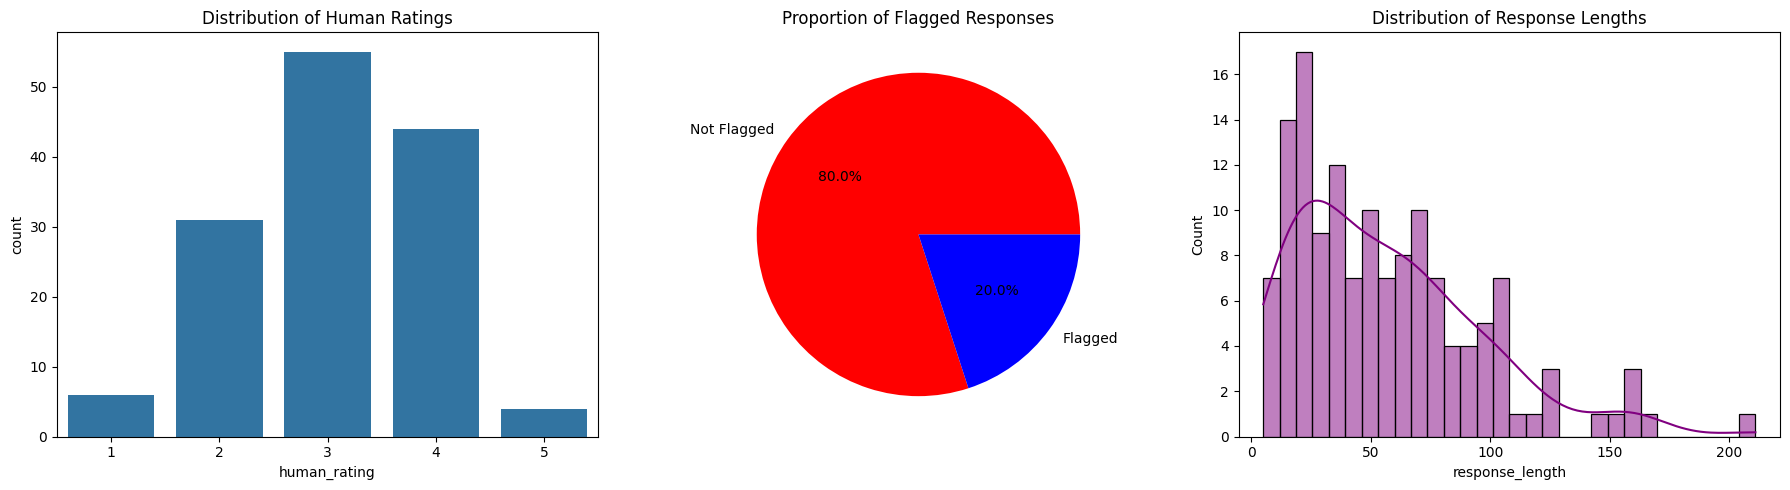

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #three different plot views

# Rating
sns.countplot(ax=axes[0], data=dataset, x='human_rating')
axes[0].set_title('Distribution of Human Ratings')

# Flagging 
flag_counts = dataset['flagging'].value_counts()
axes[1].pie(flag_counts, labels=['Not Flagged', 'Flagged'], colors=('red', 'blue'),autopct='%1.1f%%')
axes[1].set_title('Proportion of Flagged Responses')

# Response Length
sns.histplot(ax=axes[2], data=dataset, x='response_length', bins=30, kde=True, color='purple')
axes[2].set_title('Distribution of Response Lengths')

plt.show()

This is a preliminary visualization of what the datset distribution and records look like.

The first chart of human ratings shows to be mostly normally distributed. The flagging pie chart shows that the data is mostly unflagged with 80% of ai_responses being accurate. The responth length graph is left skewed, showing that majority responses are equal to or less than 100 words. 


Question 2: What are the characteristics of 5 star or 1 star human rating for flagged responses? (profiling extremes)

In [5]:
#What are the characteristics of 5 star or 1 star human rating for flagged responses? (profiling extremes)
perfect_resp = (dataset['human_rating'] == 5) & (dataset['flagging'] == 0)
terrible_resp = (dataset['human_rating'] == 1) & (dataset['flagging'] == 1)
avg_wo_extr = (dataset['human_rating']>1) & (dataset['human_rating']<5)

perfect_profile = dataset[perfect_resp][['confidence_score', 'response_length']].mean()
terrible_profile = dataset[terrible_resp][['confidence_score', 'response_length']].mean()
avg_wo_ext_profile = dataset[avg_wo_extr][['confidence_score', 'response_length']].mean()

avg_profile = dataset[['confidence_score','response_length']].mean()

profile_df = pd.DataFrame({
    'Perfect (5-star, Unflagged)': perfect_profile,
    'Terrible (1-star, Flagged)': terrible_profile,
    'Average without extremes': avg_wo_ext_profile,
    "Average profile(including extreme values)": avg_profile
})

print("Average Characteristics of Extreme Responses:")
display(profile_df.T)

Average Characteristics of Extreme Responses:


,confidence_score,response_length
"Perfect (5-star, Unflagged)",0.900000,49.666667
"Terrible (1-star, Flagged)",0.400000,6.000000
Average without extremes,0.730385,58.715385
Average profile(including extreme values),0.729286,56.785714


This is a comparative analysis of the confidence score and response length of the extreme and average human rating. The average confidence score and response length for the perfect resonse is 0.9 and 49.67 words. Simultaneously, the other extremes of a terrible response has an average confidence score of 0.4 and a 6 word response length. We conclude that there is a noticable variation in the confidence score between the extreme and average values. 

This analysis establishes preliminary evidence indicating that the confidence score paramenter <u>may be</u> correlated to human rating. 

Question3: How does the model's confidence score relate to actual human ratings? (model calibrations, investigating further)


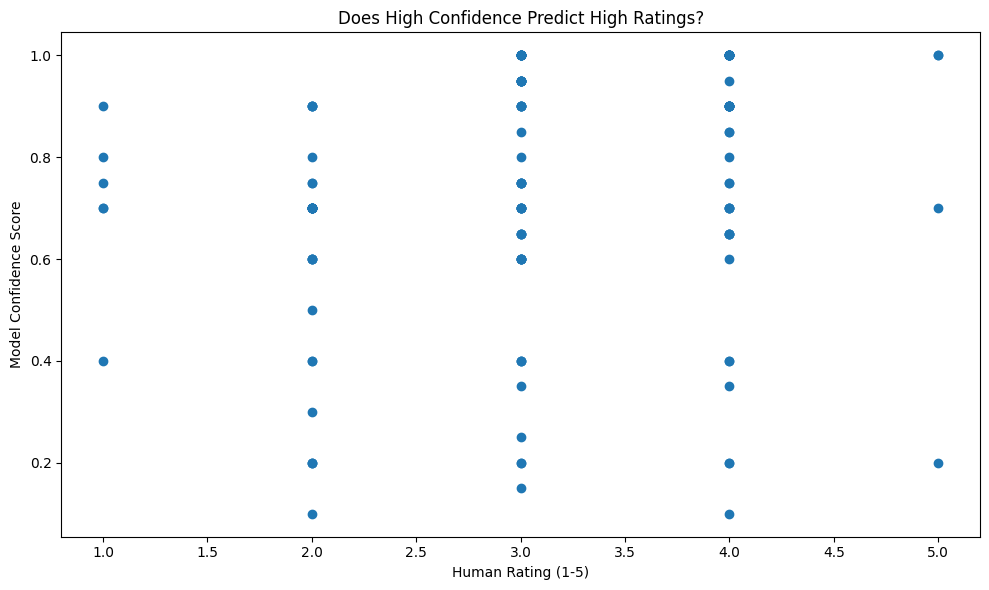

Correlation between Human Rating and Confidence Score: 0.209


In [21]:
#How does the model's confidence score relate to actual human ratings? (model calibrations)
x = dataset['human_rating']
y = dataset['confidence_score']
plt.figure(figsize=(10, 6))
plt.scatter(x, y)
#ax = sns.boxplot(data=dataset, x='human_rating', y='confidence_score')
#ax.yaxis.grid(False)
plt.title('Does High Confidence Predict High Ratings?')
plt.xlabel('Human Rating (1-5)')
plt.ylabel('Model Confidence Score')
plt.show()

correlation = dataset['human_rating'].corr(dataset['confidence_score'])
print(f"Correlation between Human Rating and Confidence Score: {correlation:.3f}")


Based on the graph above, we can conclude that our initial hypothesis stating that confidence_score and human rating could be correlated was wrong. This result aligns with the procedure used to create the dataset. Since, the human_rating column was derived by analyzing semantic sentence embeddings between the reference_answer and ai_response columns, the lack of correlation between confidence_score and human_rating is an unconstructed phenomenon of the dataset.

A low correlation that the AI model used to generate responses doesn't know when it's hallucinating.

Question 4: Are there specific question types where the model performs better?

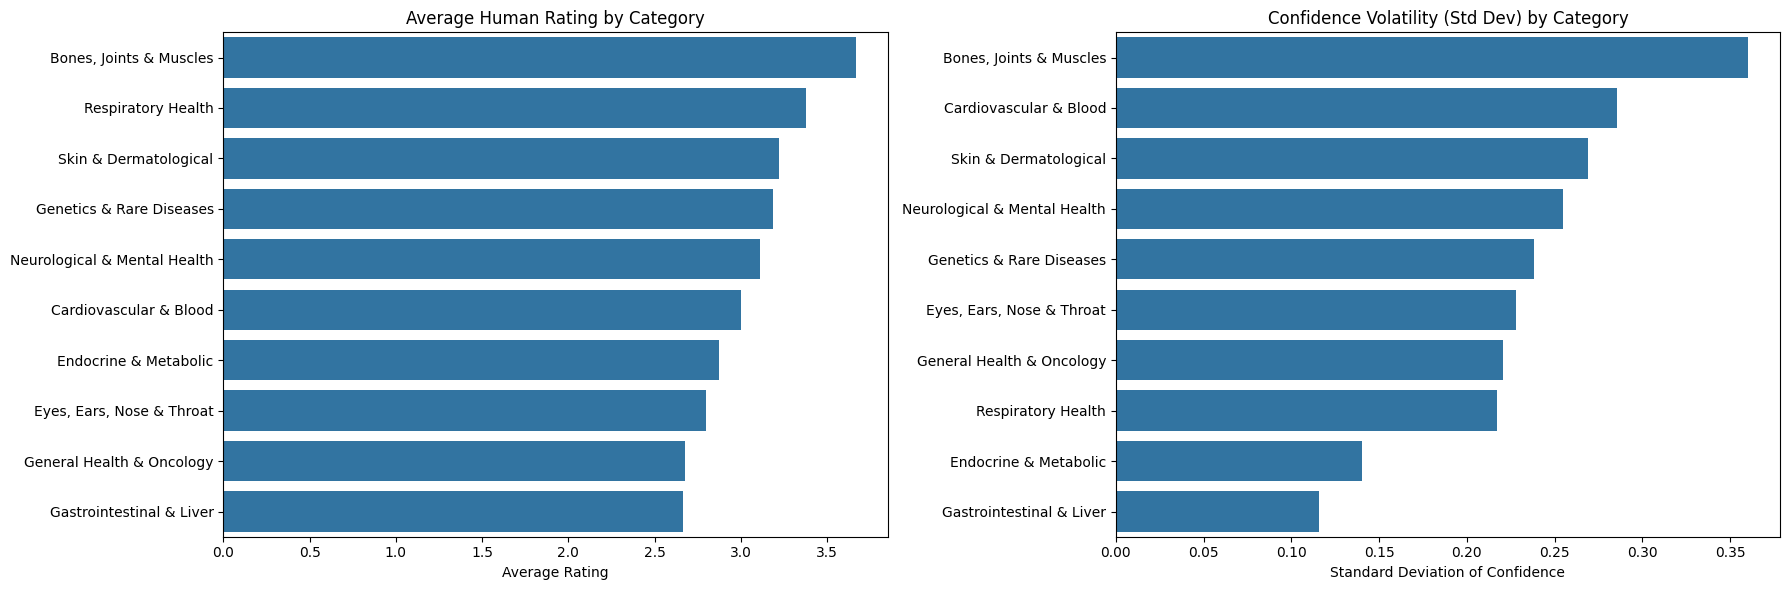

In [23]:
#Are there specific model categories where the model performs better?
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Average Rating by Category

category_order = dataset.groupby('question_type')['human_rating'].mean().sort_values(ascending=False).index
sns.barplot(ax=axes[0], data=dataset, x='human_rating', y='question_type', order=category_order, errorbar=None)
axes[0].set_title('Average Human Rating by Category')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('')

# Confidence Volatility by Category
conf_variance = dataset.groupby('question_type')['confidence_score'].std().sort_values(ascending=False)
sns.barplot(ax=axes[1], x=conf_variance.values, y=conf_variance.index)
axes[1].set_title('Confidence Volatility (Std Dev) by Category')
axes[1].set_xlabel('Standard Deviation of Confidence')
axes[1].set_ylabel('')

plt.show()


The left graph shows the top question types with respect to the mean of human ratings. This means that such a model is more appropriate for some medical fields over others, creating data bias. <br><br>
The right graph shows the volatility of the confidence score. A score above 0.15 is considered a highly voloatile category. While the top categories of average human rating have >3.0 rating, these are still some of the most volatile categories (as shown by the second graph). <br><br>


Quesiton 5: What triggers the human flag? (outliers and overconfidence)

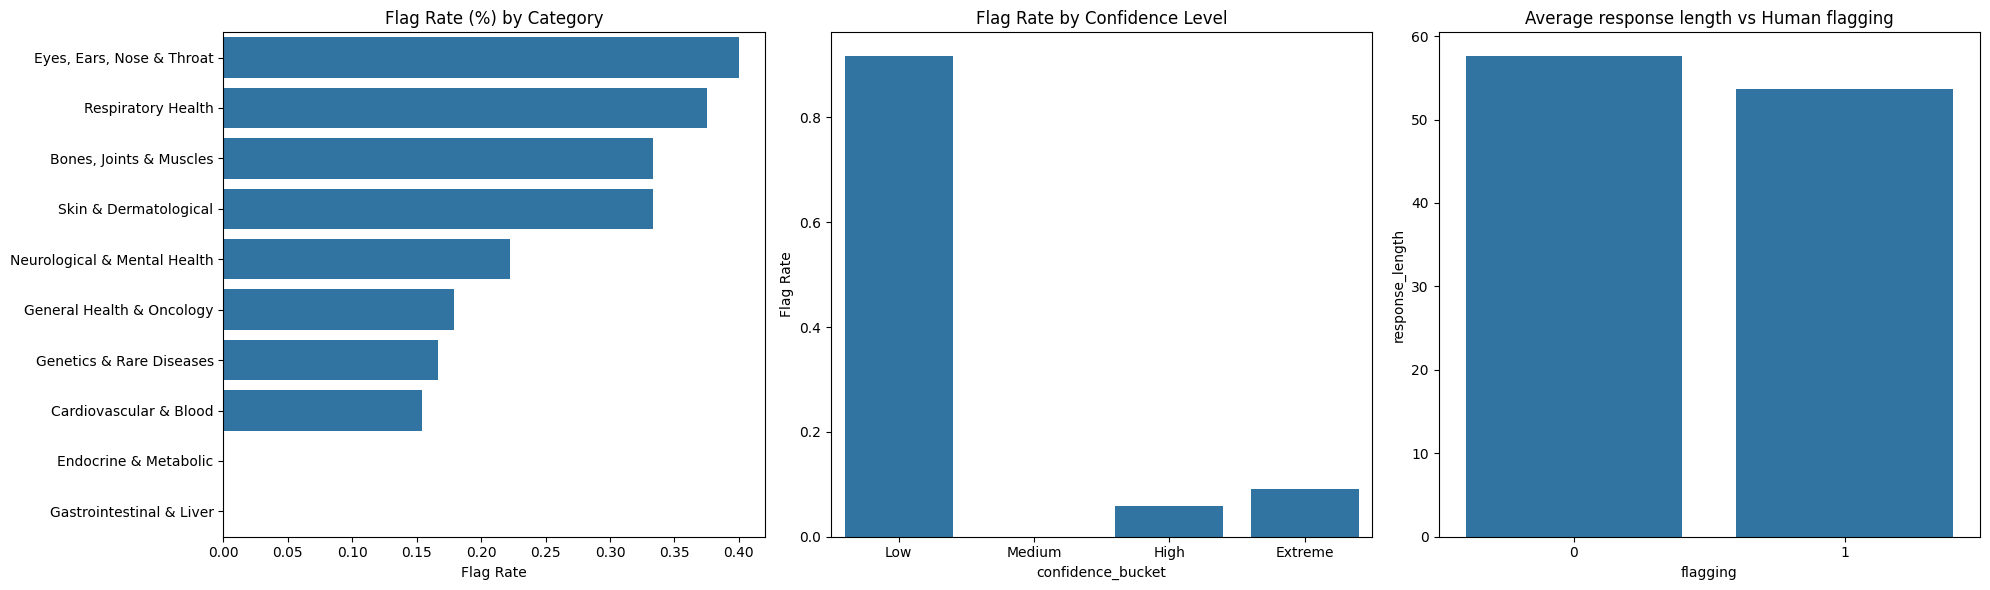

In [27]:
#What triggers the human flag? (outliers and overconfidence)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#Category Danger Zones
flag_rates = dataset.groupby('question_type')['flagging'].mean().sort_values(ascending=False)
sns.barplot(ax=axes[0], x=flag_rates.values, y=flag_rates.index)
axes[0].set_title('Flag Rate (%) by Category')
axes[0].set_xlabel('Flag Rate')
axes[0].set_ylabel('')

#Extreme Confidence vs Flagging
dataset['confidence_bucket'] = pd.cut(dataset['confidence_score'], bins=[0, 0.5, 0.7, 0.85, 1.0], labels=['Low', 'Medium', 'High', 'Extreme'])
conf_flag_rates = dataset.groupby('confidence_bucket', observed=False)['flagging'].mean()
sns.barplot(ax=axes[1], x=conf_flag_rates.index, y=conf_flag_rates.values)
axes[1].set_title('Flag Rate by Confidence Level')
axes[1].set_ylabel('Flag Rate')

#Length Outliers
sns.barplot(ax=axes[2], data=dataset, x='flagging', y='response_length' , errorbar=None)
axes[2].set_title('Average response length vs Human flagging')

#plt.tight_layout()
plt.show()



The analysis is about what factors lead to human flagging. The first graph shows that 'eyes, ears, nose, & throat category had 40% flag rate. This implies that AI could be lacking training on Eyes, Eara, Nose and Throat modeical questions. <br> <br>
The second graph shows confidence score aligns with the flag rate except a few outliers. <br> <br>
The third barchart was made to find if response length had a contribution to human rating, which it does ever so slightly. <br> <br>
These tests are inconclusive due to the size of the dataset and how the variation and volatility of AI responses is high. 



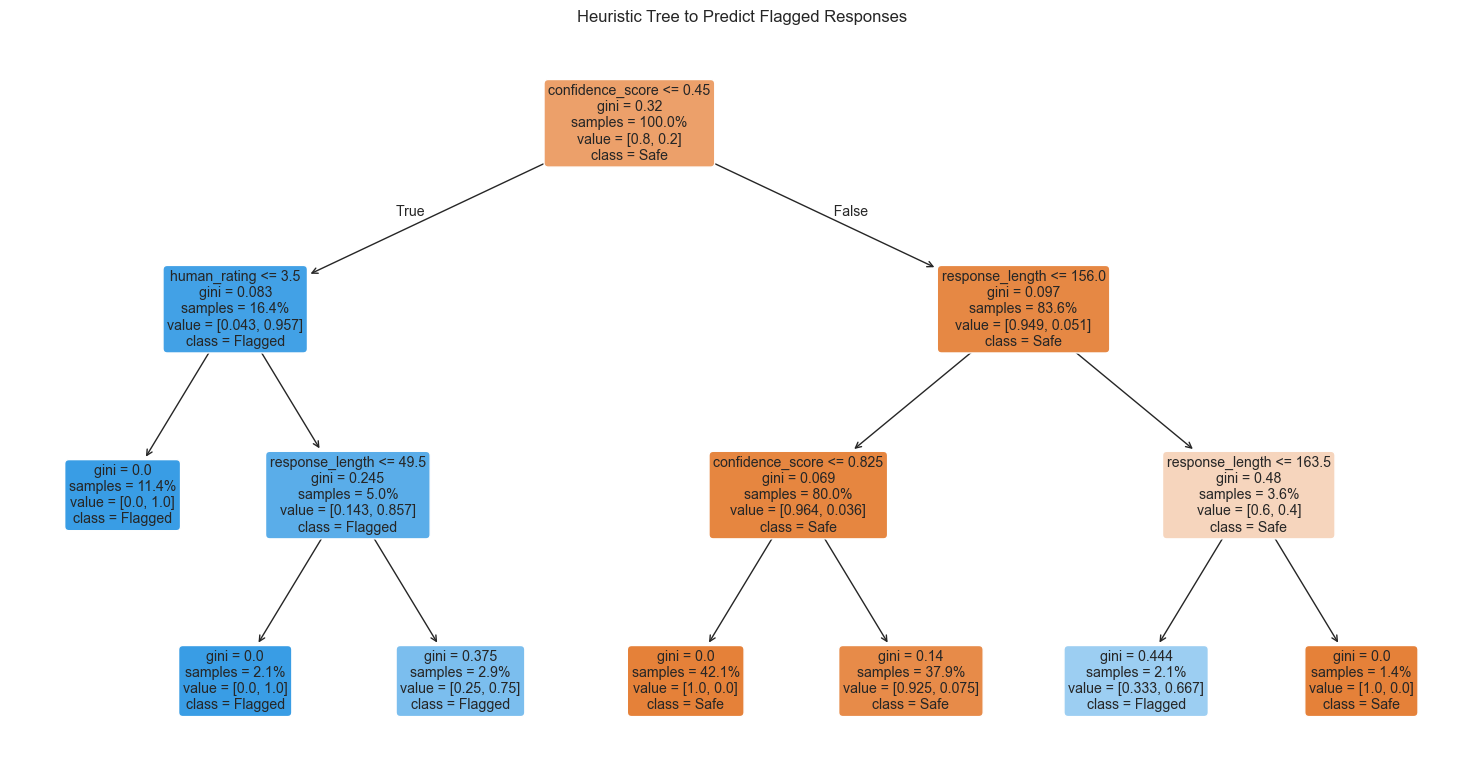

Feature Importances for Predicting a Flag:
confidence_score: 0.920
response_length: 0.074
human_rating: 0.006


In [25]:
features = ['confidence_score', 'response_length', 'human_rating']
X = dataset[features].fillna(0)
y = dataset['human_flagging']

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=features, class_names=['Safe', 'Flagged'], filled=True, rounded=True, proportion=True)
plt.title('Heuristic Tree to Predict Flagged Responses')
plt.show()

print("Feature Importances for Predicting a Flag:")
for name, importance in zip(features, clf.feature_importances_):
    print(f"{name}: {importance:.3f}")

Predictive Analytics

In [ ]:
##predictive analytics


# do not need to handle missing data points because its self-generated dataset

# question type column in one-hot encoding
dataset_encoded = pd.get_dummies(dataset, columns=['question_type'], drop_first=True)
print(dataset_encoded.columns)

#print(dataset.head())
#print(dataset_encoded.head())

Generating one-encoded mapping for all the question_type of the dataset

---

Question 7: Predicting human rating based on response length and confidence score.

In [ ]:
##linear regression
#predicting human rating based on response length and confidence score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_lin = dataset[['response_length', 'confidence_score']]
y_lin = dataset['human_rating']

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=49)

lin_model = LinearRegression().fit(X_train_lin, y_train_lin)
y_pred_lin = lin_model.predict(X_test_lin)

print("Linear Regression MSE:", mean_squared_error(y_test_lin, y_pred_lin))
print("Linear Regression R2 Score:", r2_score(y_test_lin, y_pred_lin))
print(lin_model.coef_)


Linear Regression MSE: 0.9304405831827288
Linear Regression R2 Score: 0.05017523800096435
[0.0075482 0.0908834]


What combination of length, confidence rating ,human rating, question type makes a response most likely to be flagged by users?

In [27]:
##logistic regression
##What combination of length, confidence rating ,human rating, question type makes a response most likely to be flagged by users?

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

feature_cols = ['response_length', 'confidence_score', 'human_rating'] + [c for c in dataset_encoded.columns if c.startswith('question_type_')]
X_log = dataset_encoded[feature_cols]
y_log = dataset_encoded['human_flagging']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=57, stratify=y_log)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)
y_pred_log = log_model.predict(X_test_log)

print("Logistic Regression Classification Report:")
print(classification_report(y_test_log, y_pred_log))



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        22
           1       1.00      0.33      0.50         6

    accuracy                           0.86        28
   macro avg       0.92      0.67      0.71        28
weighted avg       0.88      0.86      0.83        28



Can a non-linear machine learning model better predict which responses will be flagged? 

In [35]:
##Can a non-linear machine learning model better predict which responses will be flagged? 
##forest classifier

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_log, y_train_log)
y_pred_rf = rf_model.predict(X_test_log)

print("Random Forest Classification Report:")
print(classification_report(y_test_log, y_pred_rf))

# Feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
print("Top 3 Feature Importances + Most important question type:")
for i in range(4):
    print(f"{X_log.columns[indices[i]]}: {importances[indices[i]]:.4f}")

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        22
           1       1.00      0.83      0.91         6

    accuracy                           0.96        28
   macro avg       0.98      0.92      0.94        28
weighted avg       0.97      0.96      0.96        28

Top 3 Feature Importances + Most important question type:
confidence_score: 0.6238
response_length: 0.2137
human_rating: 0.0472
question_type_Respiratory Health: 0.0320


Is the AI better at responding to certain categories of questions, or are the variations in human rating and confidence score simply due to random chance?

--- Analysis of Human Rating by Category ---
ANOVA F-statistic: 1.4351, p-value: 1.7956e-01
Conclusion: There is NO statistically significant difference in human ratings across categories.

--- Analysis of Confidence Score by Category ---
ANOVA F-statistic: 0.9013, p-value: 5.2632e-01
Conclusion: There is NO statistically significant difference in confidence scores across categories.


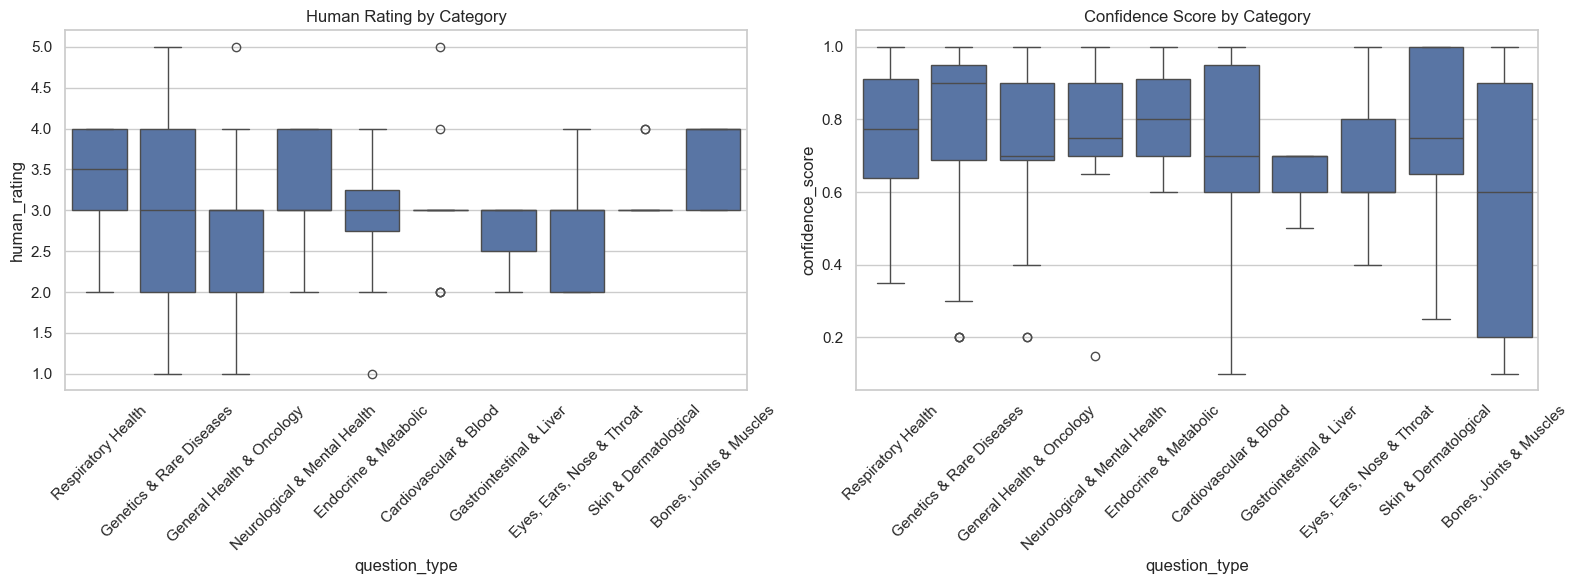

In [36]:
##Is the AI better at responding to certain categories of questions, or are the variations in human rating and confidence score simply due to random chance?
##anova testing

import scipy.stats as stats

# Group data by category
categories = dataset['question_type'].unique()

print("--- Analysis of Human Rating by Category ---")
rating_groups = [dataset[dataset['question_type'] == cat]['human_rating'] for cat in categories]
f_stat_rating, p_val_rating = stats.f_oneway(*rating_groups)
print(f"ANOVA F-statistic: {f_stat_rating:.4f}, p-value: {p_val_rating:.4e}")
if p_val_rating < 0.05:
    print("Conclusion: There IS a statistically significant difference in human ratings across categories.")
else:
    print("Conclusion: There is NO statistically significant difference in human ratings across categories.")

print("\n--- Analysis of Confidence Score by Category ---")
conf_groups = [dataset[dataset['question_type'] == cat]['confidence_score'] for cat in categories]
f_stat_conf, p_val_conf = stats.f_oneway(*conf_groups)
print(f"ANOVA F-statistic: {f_stat_conf:.4f}, p-value: {p_val_conf:.4e}")
if p_val_conf < 0.05:
    print("Conclusion: There IS a statistically significant difference in confidence scores across categories.")
else:
    print("Conclusion: There is NO statistically significant difference in confidence scores across categories.")

# Visualizing the differences
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=dataset, x='question_type', y='human_rating', ax=axes[0])
axes[0].set_title('Human Rating by Category')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=dataset, x='question_type', y='confidence_score', ax=axes[1])
axes[1].set_title('Confidence Score by Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()